This notebook is to deterministically test models for grading purpose.

# 1. Environment Setting

## A. Import Libraries

In [1]:
from __future__ import annotations
import numpy as np
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Subset, random_split, DataLoader

from torchvision import datasets, transforms
import torchvision.models as models

from sklearn.model_selection import train_test_split

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

## B. Set seed to make evaluation deterministic

In [2]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

## C. Prepare CUDA and Load Checkpoints 

In [4]:
device = torch.device("cuda")
model = models.efficientnet_b0(weights="IMAGENET1K_V1")
print(device)

cuda


In [ ]:
# Run this code block to test random split model
ckpt = torch.load('./random_enet.pth', map_location=device)

In [5]:
# Run this code block to test CB Loss model
ckpt = torch.load('./cbloss_enet.pth', map_location=device)

## D. Load Models and Datasets

In [8]:
root_dir = "PLACE YOUR DATASET ROOT DIRECTORY"
root_dir = "../../VMMRdb_Refined/VMMRdb_make_model"
transform = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(),])
dataset = datasets.ImageFolder(root=root_dir, transform=transform)
num_classes = len(dataset.classes)
print("Number of classes:", len(dataset.classes))
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)
print('Fixed the last layer.')

model.load_state_dict(ckpt['model_state_dict'])
print('model loaded successfully.')

Number of classes: 1053
Fixed the last layer.
model loaded successfully.


In [ ]:
# Run this code block to test random split model
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)
print('loader loaded successfully')

In [9]:
# Run this code block to test CB Loss model
targets = np.array(dataset.targets)
indices = np.arange(len(targets))
train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=targets,
    random_state=42
)

train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)
print('Loader loaded successfully.')

Loader loaded successfully.


## E. Move Model to Device and Turn Model into Evaluation Mode

In [10]:
model.to(device)
model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

# 2. Evaluate Model

## A. Run Evaluation and Save Results

In [12]:
all_logits = []
all_labels = []

print("eval start")
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        all_logits.append(outputs.cpu())
        all_labels.append(labels.cpu())

logits = torch.cat(all_logits)
labels = torch.cat(all_labels)
print("eval finish")

eval start
eval finish


## B. Apply Softmax and Calculate Overall Accuracy and Macro F1 Score

In [14]:
softmaxes = F.softmax(logits, dim=1)
confidences, predictions = torch.max(softmaxes, dim=1)
accuracies = predictions.eq(labels)
accuracy = accuracies.float().mean().item()
f1_macro = f1_score(labels, predictions, average='macro')
print(f"Total Accuracy: {accuracy * 100:.2f}%")
print(f"Macro F1 Score: {f1_macro}")

Total Accuracy: 83.11%
Macro F1 Score: 0.5715086437856404


# 3. Analyse Results

## A. Create Report

In [15]:
all_class_indices = list(range(num_classes))
report = classification_report(
    labels, 
    predictions, 
    labels=all_class_indices,     
    target_names=dataset.classes, 
    output_dict=True,
    zero_division=0
)
df_report = pd.DataFrame(report).transpose()
class_counts = pd.Series(labels).value_counts().sort_index()

## B. Classwise F1 Score

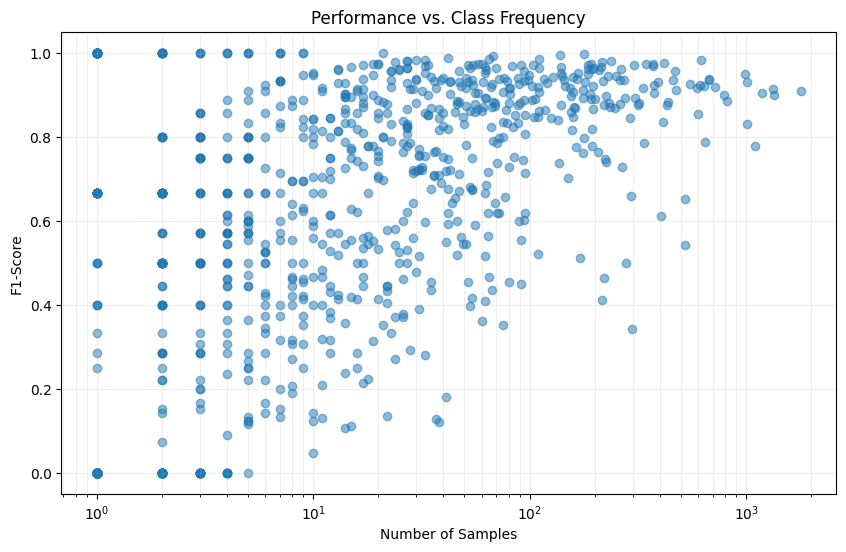

In [16]:
f1_data = []
for i, name in enumerate(dataset.classes):
    if name in df_report.index:
        f1_data.append({
            'class': name,
            'count': class_counts.get(i, 0),
            'f1-score': df_report.loc[name, 'f1-score']
        })
df_perf = pd.DataFrame(f1_data)

plt.figure(figsize=(10, 6))
plt.scatter(df_perf['count'], df_perf['f1-score'], alpha=0.5)
plt.xscale('log')
plt.xlabel('Number of Samples')
plt.ylabel('F1-Score')
plt.title('Performance vs. Class Frequency')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

## C. Classwise Accuracy in Dot graph

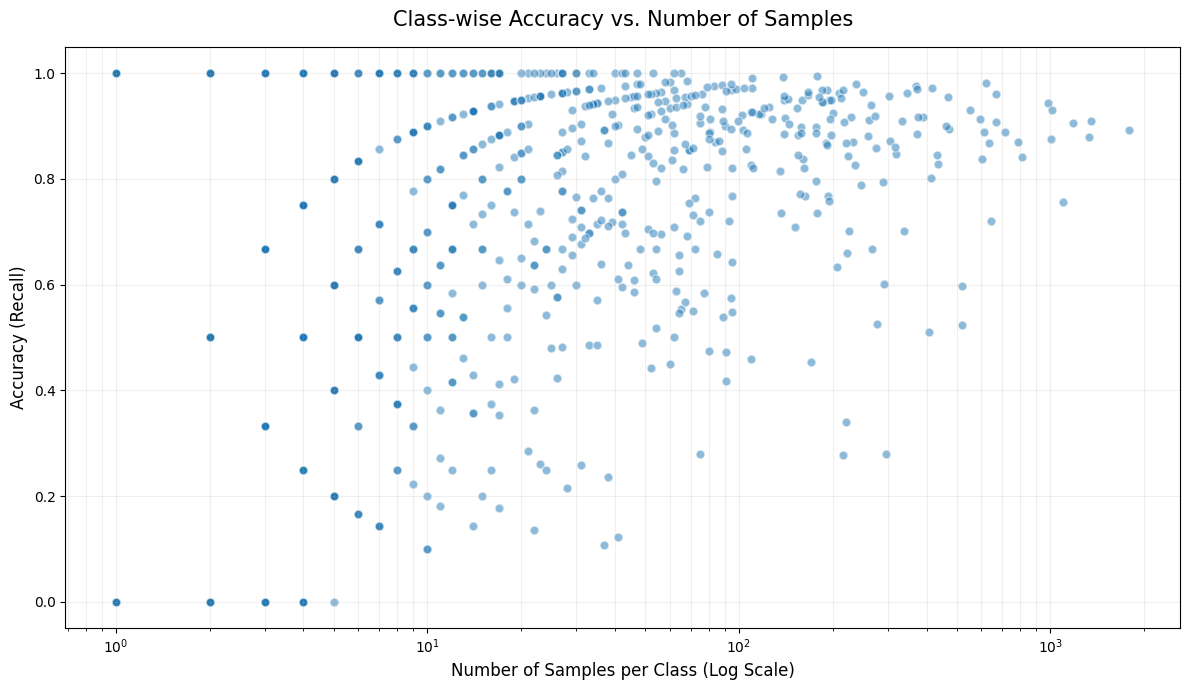

In [17]:
acc_data = []
for name in dataset.classes:
    if name in df_report.index:
        acc_data.append({
            'class': name,
            'count': df_report.loc[name, 'support'],
            'accuracy': df_report.loc[name, 'recall']
        })
df_perf = pd.DataFrame(acc_data)

plt.figure(figsize=(12, 7))
plt.scatter(df_perf['count'], df_perf['accuracy'], alpha=0.5, c='#1f77b4', edgecolors='w', s=40)
plt.xscale('log')
plt.ylim(-0.05, 1.05) 
plt.title('Class-wise Accuracy vs. Number of Samples', fontsize=15, pad=15)
plt.xlabel('Number of Samples per Class (Log Scale)', fontsize=12)
plt.ylabel('Accuracy (Recall)', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()
plt.show()

## D. Classwise Average Accuracy

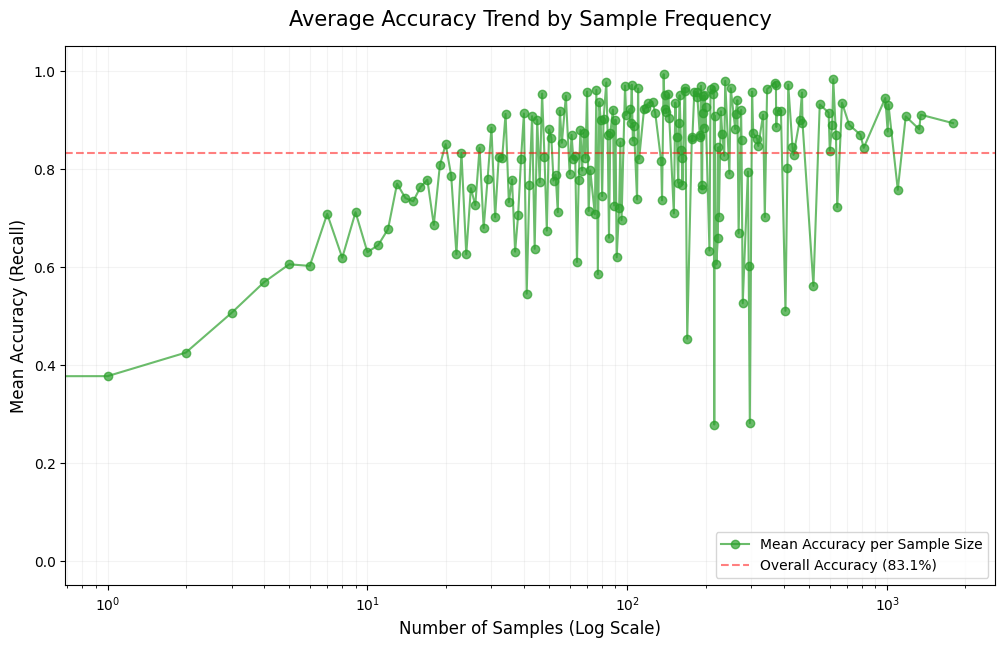

In [18]:

avg_acc_data = []
for name in dataset.classes:
    if name in report:
        avg_acc_data.append({
            'count': report[name]['support'],
            'accuracy': report[name]['recall']
        })
df = pd.DataFrame(avg_acc_data)
df_avg = df.groupby('count')['accuracy'].mean().reset_index()

plt.figure(figsize=(12, 7))
plt.plot(df_avg['count'], df_avg['accuracy'], marker='o', linestyle='-', 
            color='#2ca02c', markersize=6, alpha=0.7, label='Mean Accuracy per Sample Size')
plt.xscale('log')
plt.ylim(-0.05, 1.05)
overall_acc = np.mean(predictions.numpy() == labels.numpy())
plt.axhline(y=overall_acc, color='r', linestyle='--', alpha=0.5, 
            label=f'Overall Accuracy ({overall_acc*100:.1f}%)')
plt.title('Average Accuracy Trend by Sample Frequency', fontsize=15, pad=15)
plt.xlabel('Number of Samples (Log Scale)', fontsize=12)
plt.ylabel('Mean Accuracy (Recall)', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.15)
plt.legend(loc='lower right')
plt.show()